# Chapter 2 Companion Notebook: Python for Financial Analysis

This notebook reproduces every code example from Chapter 2 of *AI in Finance* (`chapter2.tex`), including the two-asset portfolio worked example that runs through the whole chapter, and the control-flow, data-structure, boolean-indexing, merge/groupby/resample, scaling-up, performance-comparison, and error-handling material added in the expanded chapter.

## 1. A first Python session

In [1]:
def future_value(price, rate, periods=1):
    return price * (1 + rate) ** periods

print(future_value(100.0, 0.08))
print(future_value(100.0, 0.08, periods=3))

108.0
125.97120000000001


## 2. Control flow: conditionals and loops

An `if`/`elif`/`else` chain classifies a return; a `for` loop applies it to a list. A separate loop computes a sequentially dependent running balance, which cannot be vectorized because each month's balance depends on the previous one.

In [2]:
def classify_return(r):
    if r > 0.01:
        return "strong gain"
    elif r > 0:
        return "small gain"
    elif r == 0:
        return "flat"
    else:
        return "loss"

for r in [0.02, 0.004, 0.0, -0.015]:
    print(r, "->", classify_return(r))

balance = 0.0
monthly_deposit = 200.0
monthly_rate = 0.004  # roughly 5% annual, compounded monthly

for month in range(1, 13):
    balance = balance * (1 + monthly_rate) + monthly_deposit

print(round(balance, 2))

0.02 -> strong gain
0.004 -> small gain
0.0 -> flat
-0.015 -> loss
2453.51


## 3. Core data structures: building the running price example

In [3]:
import numpy as np
import pandas as pd

dates = pd.date_range('2024-01-02', periods=5, freq='B')
prices = pd.DataFrame(
    {
        'AssetA': [100.00, 102.00, 101.00, 104.00, 103.00],
        'AssetB': [50.00, 50.50, 51.26, 51.00, 52.02],
    },
    index=dates,
)
prices

,AssetA,AssetB
2024-01-02,100.0,50.00
2024-01-03,102.0,50.50
2024-01-04,101.0,51.26
2024-01-05,104.0,51.00
2024-01-08,103.0,52.02


## 4. Dictionaries, tuples, and list comprehensions

A dictionary maps descriptive keys to values; a list of dictionaries converts directly into a `DataFrame`; a tuple is an immutable pairing such as a (bid, ask) quote; and list comprehensions build a new list compactly, optionally with a filtering condition.

In [4]:
security_info = {
    "ticker": "AAPL",
    "sector": "Technology",
    "shares_outstanding": 15_500_000_000,
    "is_dividend_payer": True,
}
print(security_info["sector"])

securities = [
    {"ticker": "AAPL", "sector": "Technology", "price": 190.50},
    {"ticker": "JPM", "sector": "Financials", "price": 145.20},
    {"ticker": "XOM", "sector": "Energy", "price": 102.75},
]
securities_df = pd.DataFrame(securities)
print(securities_df)

quote = (100.20, 100.35)  # (bid, ask), a tuple: immutable by design
print(quote)

prices_list = [190.50, 145.20, 102.75]
price_labels = [f"${p:,.2f}" for p in prices_list]
print(price_labels)

# a comprehension with a condition: tickers priced above $150
expensive = [s["ticker"] for s in securities if s["price"] > 150]
print(expensive)

Technology
  ticker      sector   price
0   AAPL  Technology  190.50
1    JPM  Financials  145.20
2    XOM      Energy  102.75
(100.2, 100.35)
['$190.50', '$145.20', '$102.75']
['AAPL']


## 5. Returns with NumPy and pandas (vectorization)

In [5]:
asset_a = prices['AssetA'].to_numpy()
returns_a = (asset_a[1:] - asset_a[:-1]) / asset_a[:-1]
print(np.round(returns_a, 4))
print(round(returns_a.mean(), 4), round(returns_a.std(ddof=1), 4))

[ 0.02   -0.0098  0.0297 -0.0096]
0.0076 0.0203


## 6. Boolean indexing and vectorized conditionals

A boolean mask selects or counts observations without a loop; `np.select` generalizes an `if`/`elif` chain into a single vectorized expression, reproducing `classify_return` applied to all four returns at once.

In [6]:
up_days = returns_a > 0
print(up_days)
print(f"Number of up days: {up_days.sum()}")
print(f"Average return on up days: {returns_a[up_days].mean():.4f}")

conditions = [returns_a > 0.01, returns_a > 0, returns_a == 0]
choices = ["strong gain", "small gain", "flat"]
labels = np.select(conditions, choices, default="loss")
print(labels)

[ True False  True False]
Number of up days: 2
Average return on up days: 0.0249
['strong gain' 'loss' 'strong gain' 'loss']


In [7]:
returns = prices.pct_change().dropna()
returns.round(4)

,AssetA,AssetB
2024-01-03,0.0200,0.0100
2024-01-04,-0.0098,0.0150
2024-01-05,0.0297,-0.0051
2024-01-08,-0.0096,0.0200


## 7. Combining and reshaping data: merge, groupby, and resample

`merge` aligns two tables on a shared key (like a SQL join); `groupby` aggregates by a categorical column; `resample` aggregates a time-indexed series to a coarser frequency.

In [8]:
securities_df2 = pd.DataFrame([
    {"ticker": "AAPL", "sector": "Technology", "price": 190.50},
    {"ticker": "JPM", "sector": "Financials", "price": 145.20},
    {"ticker": "XOM", "sector": "Energy", "price": 102.75},
    {"ticker": "MSFT", "sector": "Technology", "price": 375.10},
])
shares = pd.DataFrame({
    "ticker": ["AAPL", "JPM", "XOM", "MSFT"],
    "shares_held": [100, 50, 200, 30],
})

merged = securities_df2.merge(shares, on="ticker")
merged["position_value"] = merged["price"] * merged["shares_held"]
print(merged)

sector_summary = merged.groupby("sector")["position_value"].sum()
print(sector_summary)

  ticker      sector   price  shares_held  position_value
0   AAPL  Technology  190.50          100         19050.0
1    JPM  Financials  145.20           50          7260.0
2    XOM      Energy  102.75          200         20550.0
3   MSFT  Technology  375.10           30         11253.0
sector
Energy        20550.0
Financials     7260.0
Technology    30303.0
Name: position_value, dtype: float64


In [9]:
extended_dates = pd.date_range("2024-01-02", periods=10, freq="B")
extended_prices = pd.Series(
    [100.00, 102.00, 101.00, 104.00, 103.00, 105.00, 107.00, 106.00, 108.00, 110.00],
    index=extended_dates, name="AssetA",
)
weekly_last = extended_prices.resample("W-FRI").last()
print(weekly_last)

weekly_return = weekly_last.pct_change().dropna()
print(weekly_return.round(4))

2024-01-05    104.0
2024-01-12    108.0
2024-01-19    110.0
Freq: W-FRI, Name: AssetA, dtype: float64
2024-01-12    0.0385
2024-01-19    0.0185
Freq: W-FRI, Name: AssetA, dtype: float64


## 7b. Visualization

Reproduces the three charts from Chapter 2's Visualization section. The chapter's own four-observation `AssetA`/`AssetB` example is too short to make a histogram or scatter plot visually informative, so this section simulates a longer, one-year (252 trading day) two-asset price history with a similar negative correlation between the assets, used only for these three plots. Each figure is saved as a PNG and embedded directly in `chapter2.tex`.

In [10]:
rng_viz = np.random.default_rng(6)
n_days = 252
mean_returns = [0.0006, 0.0004]
vols = [0.015, 0.010]
corr_viz = -0.6
cov_viz = [
    [vols[0] ** 2, corr_viz * vols[0] * vols[1]],
    [corr_viz * vols[0] * vols[1], vols[1] ** 2],
]

daily_returns_viz = rng_viz.multivariate_normal(mean_returns, cov_viz, size=n_days)
dates_viz = pd.bdate_range("2024-01-02", periods=n_days)
returns_viz = pd.DataFrame(daily_returns_viz, index=dates_viz, columns=["AssetA", "AssetB"])

prices_viz = pd.DataFrame({
    "AssetA": 100 * (1 + returns_viz["AssetA"]).cumprod(),
    "AssetB": 50 * (1 + returns_viz["AssetB"]).cumprod(),
})

print(f"Realized correlation over {n_days} simulated days: "
      f"{returns_viz['AssetA'].corr(returns_viz['AssetB']):.3f}")

Realized correlation over 252 simulated days: -0.641


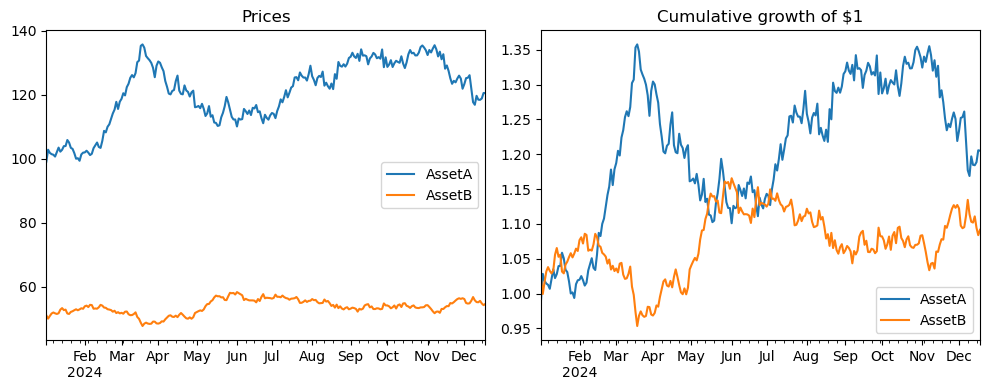

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
prices_viz.plot(ax=axes[0], title="Prices")
(1 + returns_viz).cumprod().plot(ax=axes[1], title="Cumulative growth of $1")
plt.tight_layout()
plt.savefig("../ch2_fig_prices_growth.png", dpi=150)
plt.show()

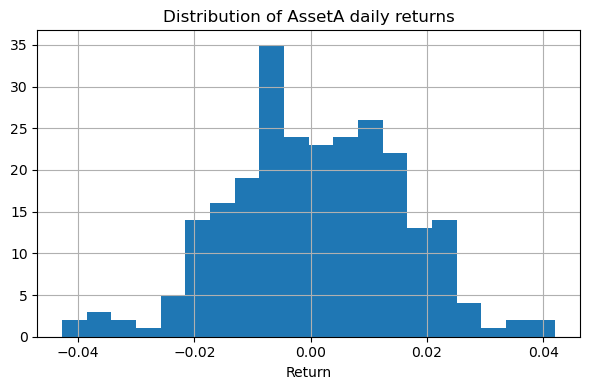

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
returns_viz["AssetA"].hist(ax=ax, bins=20)
ax.set_title("Distribution of AssetA daily returns")
ax.set_xlabel("Return")
plt.tight_layout()
plt.savefig("../ch2_fig_histogram.png", dpi=150)
plt.show()

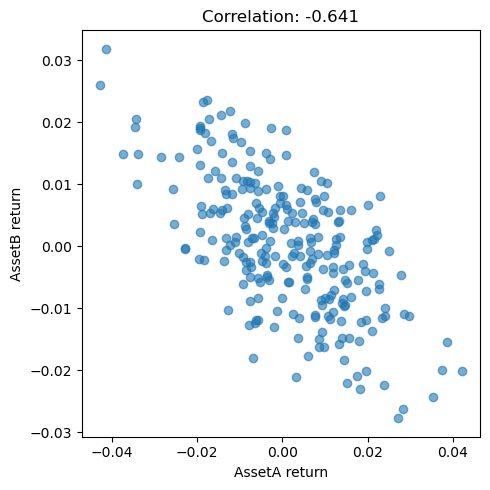

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(returns_viz["AssetA"], returns_viz["AssetB"], alpha=0.6)
ax.set_xlabel("AssetA return")
ax.set_ylabel("AssetB return")
ax.set_title(f"Correlation: {returns_viz['AssetA'].corr(returns_viz['AssetB']):.3f}")
plt.tight_layout()
plt.savefig("../ch2_fig_scatter.png", dpi=150)
plt.show()

## 8. Data cleaning: a simulated missing value and forward-fill

In [14]:
raw = prices.copy()
raw.loc['2024-01-04', 'AssetB'] = np.nan
cleaned = raw.ffill()
print(raw['AssetB'].isna().sum(), 'missing value(s) before cleaning')
print(cleaned['AssetB'].isna().sum(), 'missing value(s) after cleaning')

1 missing value(s) before cleaning
0 missing value(s) after cleaning


## 9. The worked two-asset portfolio example

This reproduces every number quoted in Section 2.13 of the chapter.

In [15]:
weights = np.array([0.5, 0.5])
portfolio_returns = returns.dot(weights)
print(portfolio_returns.round(4))

port_mean = portfolio_returns.mean()
port_vol = portfolio_returns.std(ddof=1)
print(round(port_mean, 4), round(port_vol, 4))

2024-01-03    0.0150
2024-01-04    0.0026
2024-01-05    0.0123
2024-01-08    0.0052
Freq: B, dtype: float64
0.0088 0.0058


In [16]:
cov_matrix = returns.cov()
print(cov_matrix.round(6))

corr = returns.corr().iloc[0, 1]
print(round(corr, 3))

          AssetA    AssetB
AssetA  0.000414 -0.000198
AssetB -0.000198  0.000118
-0.896


In [17]:
# Verify the portfolio-variance formula against the direct computation
var_A, var_B, cov_AB = cov_matrix.iloc[0, 0], cov_matrix.iloc[1, 1], cov_matrix.iloc[0, 1]
wA, wB = weights
portfolio_variance_formula = wA**2 * var_A + wB**2 * var_B + 2 * wA * wB * cov_AB
portfolio_variance_direct = portfolio_returns.var(ddof=1)

print(f"Formula-based variance: {portfolio_variance_formula:.8f}")
print(f"Direct variance:        {portfolio_variance_direct:.8f}")
print(f"Formula-based volatility: {np.sqrt(portfolio_variance_formula):.4f}")

weighted_avg_vol = wA * returns['AssetA'].std(ddof=1) + wB * returns['AssetB'].std(ddof=1)
print(f"Weighted average of individual volatilities: {weighted_avg_vol:.4f}")
print(f"Actual portfolio volatility:                 {portfolio_returns.std(ddof=1):.4f}")
print("The portfolio volatility is far below the weighted average, "
      "the diversification effect from a strongly negative correlation.")

Formula-based variance: 0.00003399
Direct variance:        0.00003399
Formula-based volatility: 0.0058
Weighted average of individual volatilities: 0.0156
Actual portfolio volatility:                 0.0058
The portfolio volatility is far below the weighted average, the diversification effect from a strongly negative correlation.


## 10. Scaling up: from two assets to a small portfolio universe

Adding a third asset requires only adding a column; none of the return, covariance, or portfolio-variance code needs to change.

In [18]:
prices["AssetC"] = [200.00, 198.00, 202.00, 199.00, 203.00]
returns3 = prices.pct_change().dropna()
print(returns3.round(4))

weights3 = np.array([1/3, 1/3, 1/3])
port3 = returns3.dot(weights3)
print(port3.round(4))

cov3 = returns3.cov()
port_var3 = weights3 @ cov3.values @ weights3
print(f"Equal-weighted 3-asset portfolio volatility: {np.sqrt(port_var3):.4f}")

            AssetA  AssetB  AssetC
2024-01-03  0.0200  0.0100 -0.0100
2024-01-04 -0.0098  0.0150  0.0202
2024-01-05  0.0297 -0.0051 -0.0149
2024-01-08 -0.0096  0.0200  0.0201
2024-01-03    0.0067
2024-01-04    0.0085
2024-01-05    0.0033
2024-01-08    0.0102
Freq: B, dtype: float64
Equal-weighted 3-asset portfolio volatility: 0.0030


## 11. Rolling statistics and descriptive summary

In [19]:
rolling_vol = returns['AssetA'].rolling(window=2).std()
rolling_vol.round(4)

2024-01-03       NaN
2024-01-04    0.0211
2024-01-05    0.0279
2024-01-08    0.0278
Freq: B, Name: AssetA, dtype: float64

In [20]:
returns.describe().round(4)

,AssetA,AssetB
count,4.0000,4.0000
mean,0.0076,0.0100
std,0.0203,0.0108
min,-0.0098,-0.0051
25%,-0.0097,0.0062
50%,0.0052,0.0125
75%,0.0224,0.0163
max,0.0297,0.0200


## 12. Why vectorization matters: a performance comparison

Compute the cumulative growth of \$1 across 100,000 simulated daily returns, once with an explicit loop and once with NumPy's vectorized `cumprod`. The exact speedup is machine-dependent, but a factor of 10-100x is typical.

In [21]:
import time

rng = np.random.default_rng(0)
simulated_returns = rng.normal(0.0005, 0.01, 100_000)

start = time.perf_counter()
total = 1.0
loop_values = []
for r in simulated_returns:
    total *= (1 + r)
    loop_values.append(total)
loop_time = time.perf_counter() - start

start = time.perf_counter()
vectorized_values = np.cumprod(1 + simulated_returns)
vector_time = time.perf_counter() - start

print(f"Loop: {loop_time:.4f}s, Vectorized: {vector_time:.4f}s, "
      f"speedup: {loop_time/vector_time:.0f}x")
print("Final values match:", np.isclose(loop_values[-1], vectorized_values[-1]))

Loop: 0.1099s, Vectorized: 0.0031s, speedup: 36x
Final values match: True


## 13. Handling errors and common pitfalls

`try`/`except` lets a program catch an error, such as a division by zero, and respond deliberately (e.g. returning `nan`) rather than crashing.

In [22]:
def safe_return(price_now, price_before):
    try:
        return (price_now - price_before) / price_before
    except ZeroDivisionError:
        return float("nan")

print(safe_return(105.0, 100.0))
print(safe_return(105.0, 0.0))

# Floating-point pitfall: use np.isclose, not ==
print(0.1 + 0.2 == 0.3)
print(np.isclose(0.1 + 0.2, 0.3))

0.05
nan
False
True


## Exercises (match Chapter 2, Suggested Exercises)

1. Compute the volatility of a 70/30 portfolio (70% AssetA, 30% AssetB) using both the formula and a direct computation.
2. Recompute the portfolio volatility assuming a correlation of +0.90 between the two assets, holding their individual volatilities fixed, and compare to the actual (negatively correlated) case above.

In [23]:
# Exercise 1: 70/30 portfolio
w70 = np.array([0.7, 0.3])
port_70_30 = returns.dot(w70)
var_formula_70_30 = w70[0]**2*var_A + w70[1]**2*var_B + 2*w70[0]*w70[1]*cov_AB
print(f"70/30 portfolio volatility (direct):  {port_70_30.std(ddof=1):.4f}")
print(f"70/30 portfolio volatility (formula):  {np.sqrt(var_formula_70_30):.4f}")

# Exercise 2: hypothetical +0.90 correlation, same individual vols
std_A, std_B = returns['AssetA'].std(ddof=1), returns['AssetB'].std(ddof=1)
cov_AB_pos = 0.90 * std_A * std_B
var_pos_corr = 0.25*std_A**2 + 0.25*std_B**2 + 2*0.25*cov_AB_pos
print(f"Portfolio volatility with corr=+0.90 (hypothetical): {np.sqrt(var_pos_corr):.4f}")
print(f"Portfolio volatility with actual corr=-0.896:        {port_vol:.4f}")

70/30 portfolio volatility (direct):  0.0114
70/30 portfolio volatility (formula):  0.0114
Portfolio volatility with corr=+0.90 (hypothetical): 0.0152
Portfolio volatility with actual corr=-0.896:        0.0058
